# Lab05：從 Anomaly Score 到值得通知的 Incident

核心問題：detector 已經能找到異常後，哪些 signal 真的值得通知人？

本 Lab 不再訓練 detector。Mahalanobis 與 LOF score 已預先產生，我們把注意力放在 production-like monitoring pipeline：狀態、時間、通知政策與可觀測性。Notebook 可離線閱讀；實作時再啟動 Docker Compose，依表格操作 Prometheus、Alertmanager 與 Grafana。

我們會把資料中的異常轉成 Prometheus 告警，並分開衡量 detector、policy 與 notification latency。

## 1. Detector output 不是 incident

主線是：

`raw anomaly scores → threshold → deduplication → hysteresis → grouping → suppression / inhibition → incident`

- **Prometheus** 把連續 score 轉成 pending／firing／resolved alert state。
- **Alertmanager** 負責 deduplication、grouping、inhibition、Silence、routing 與 notification timing。
- **receiver** 代表真正的 chat／pager destination，保存「實際送出幾次」。
- **Grafana** 只負責觀察，不替 pipeline 做決策。

因此 alert、notification、incident 是三個不同單位。`repeat_interval` 可能讓同一個 alert episode 產生多次 notification；多個 alerts 也可能被合成一次 notification。

## 2. Production-like pipeline 與 production pipeline

教室版從 canonical CSV 讀取預先計算好的 scores；真實 production 則由 telemetry ingestion 與線上 detector 持續產生 scores。兩者下游介面一致，所以 alert policy 可以原樣練習。

| Stage | Lab05 | Production counterpart |
| --- | --- | --- |
| Telemetry / detector | CSV replayer | exporter, stream, online detector |
| State evaluation | Prometheus rules | HA rule evaluators |
| Notification policy | Alertmanager | HA Alertmanager cluster / paging platform |
| Receiver | local JSONL webhook | Slack, Teams, email, PagerDuty, ticketing |
| Observation | Grafana | dashboard, SLO, audit and on-call analytics |

Production 還會需要 authentication、TLS、secrets、HA、durable remote storage、backup、RBAC、capacity planning 與 change review；Docker Compose 在此是可重現的單機教學環境，不是假裝已經完成 production hardening。

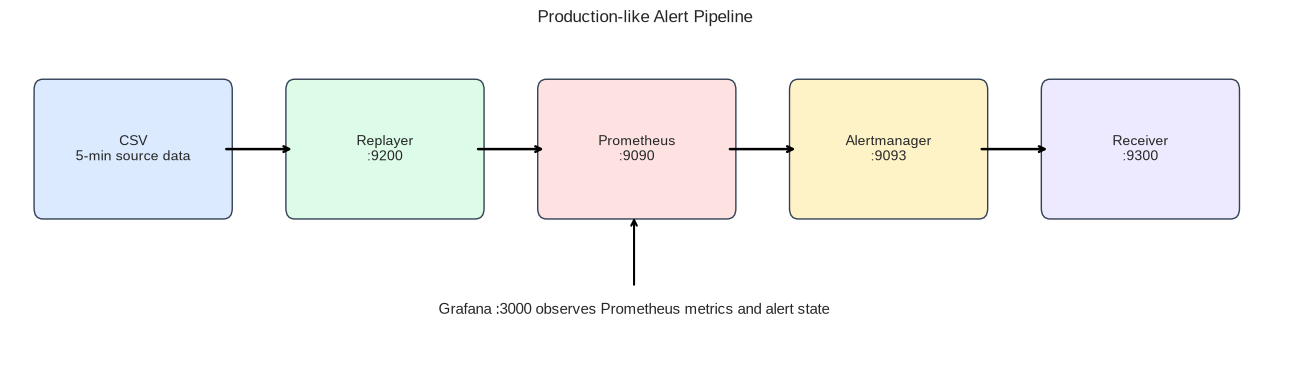

In [1]:
from pathlib import Path
import json
import math
import os
from urllib.error import URLError
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 20)

fig, ax = plt.subplots(figsize=(13, 3.8))
nodes = [
    (0.5, "CSV\n5-min source data", "#dbeafe"),
    (2.8, "Replayer\n:9200", "#dcfce7"),
    (5.1, "Prometheus\n:9090", "#fee2e2"),
    (7.4, "Alertmanager\n:9093", "#fef3c7"),
    (9.7, "Receiver\n:9300", "#ede9fe"),
]
for x, label, color in nodes:
    box = FancyBboxPatch((x, 1.25), 1.65, 0.9, boxstyle="round,pad=0.08", fc=color, ec="#334155")
    ax.add_patch(box); ax.text(x + 0.825, 1.7, label, ha="center", va="center", fontsize=10)
for left, right in zip(nodes[:-1], nodes[1:]):
    ax.annotate("", xy=(right[0], 1.7), xytext=(left[0] + 1.65, 1.7), arrowprops={"arrowstyle": "->", "lw": 1.8})
ax.text(5.9, 0.45, "Grafana :3000 observes Prometheus metrics and alert state", ha="center", fontsize=11)
ax.annotate("", xy=(5.9, 1.2), xytext=(5.9, 0.65), arrowprops={"arrowstyle": "->", "lw": 1.5})
ax.set(xlim=(0.2, 11.8), ylim=(0.1, 2.6), title="Production-like Alert Pipeline")
ax.axis("off"); plt.tight_layout(); plt.show()

### Docker Compose 在本 Lab 解決什麼？

`infra/lab05/compose.yaml` 一次固定五個服務的版本、container network、host ports、read-only configuration mounts、persistent volumes、health checks 與啟動順序。

- Container 之間用 service name，例如 `prometheus:9090`；瀏覽器才用 `localhost:9090`。
- Prometheus TSDB、Alertmanager state、Grafana state 與 receiver history 使用 named volumes；`docker compose down` 不會刪除它們，除非另加 `-v`。
- active YAML 以 read-only bind mount 提供；學生只修改 repo 裡的檔案，再執行 `check` 與 `reload`。
- image 使用 exact tags，而非 `latest`，讓全班取得一致行為。

啟動指令：

```bash
docker compose -f infra/lab05/compose.yaml up -d --build
python labs/workshop/lab05_control.py health
```

### 哪些部分仍不是 production？

Compose 是 production 常用容器映像的組裝方式之一，但單機 Compose 本身沒有高可用性。真實部署通常會把設定變更放進 Git review／CI validation，服務使用 TLS 與認證，secret 不寫進 YAML；Prometheus 可能搭配 remote-write，Alertmanager 以 cluster 去重，receiver 則是有 SLA 的外部系統。Lab05 的目的，是保留真實元件與責任邊界，同時把等待時間壓到課堂可操作的尺度。

In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "synthetic" / "lab05_replay_metrics.csv").exists():
            return candidate
    raise FileNotFoundError("Cannot locate repository root")

ROOT = find_repo_root()
DATA = ROOT / "data" / "synthetic"
metrics = pd.read_csv(DATA / "lab05_replay_metrics.csv", parse_dates=["source_timestamp"])
events = pd.read_csv(DATA / "lab05_event_catalog.csv", parse_dates=["start_time", "end_time"])

SOURCE_CADENCE_SECONDS = 300
THRESHOLD = 3.0
SCENARIOS = ["P1", "P2", "P3", "P4", "full_incident"]

summary = (metrics.groupby("scenario_id")
           .agg(points=("sample_index", "nunique"), targets=("target", "nunique"),
                start=("source_timestamp", "min"), end=("source_timestamp", "max"))
           .reindex(SCENARIOS))
display(summary)

,points,targets,start,end
scenario_id,,,,
P1,24,3,2026-04-06 09:00:00,2026-04-06 10:55:00
P2,36,3,2026-04-07 09:00:00,2026-04-07 11:55:00
P3,30,3,2026-04-08 09:00:00,2026-04-08 11:25:00
P4,36,3,2026-04-09 09:00:00,2026-04-09 11:55:00
full_incident,60,3,2026-04-10 09:00:00,2026-04-10 13:55:00


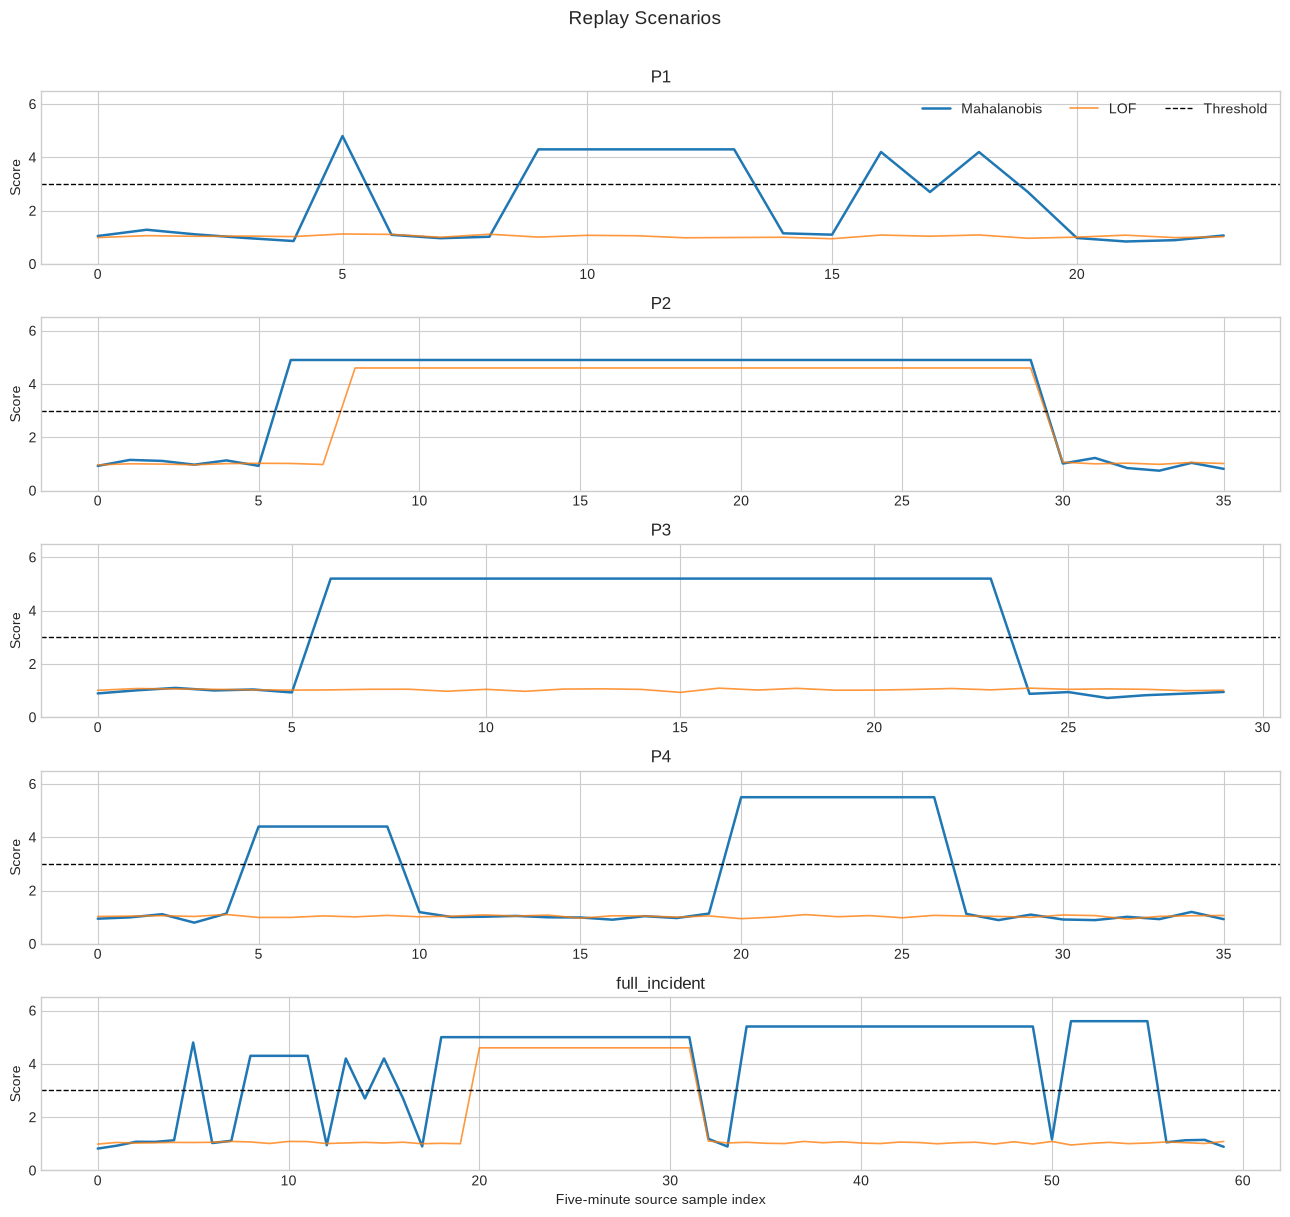

In [3]:
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(13, 12), sharex=False)
for ax, scenario in zip(axes, SCENARIOS):
    part = metrics.query("scenario_id == @scenario and target == 'fw01'")
    ax.plot(part["sample_index"], part["mahalanobis_score"], label="Mahalanobis", lw=1.8)
    ax.plot(part["sample_index"], part["lof_score"], label="LOF", lw=1.2, alpha=.8)
    ax.axhline(THRESHOLD, color="black", ls="--", lw=1, label="Threshold" if scenario == "P1" else None)
    ax.set(title=scenario, ylabel="Score", ylim=(0, 6.5))
axes[0].legend(ncol=3, loc="upper right")
axes[-1].set_xlabel("Five-minute source sample index")
fig.suptitle("Replay Scenarios", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

## 3. 雙時鐘：保留五分鐘語意，但不用真的等五分鐘

資料的 **source clock** 永遠是五分鐘一點：$Delta t_{source}=300\text{ s}$。Replayer 的 **wall/replay clock** 用可調速度 $S$ 加速：

$$
\Delta t_{replay}=\frac{\Delta t_{source}}{S}=\frac{300}{S}\text{ s}
$$

若來源事件持續 $D_{source}$ 秒，課堂上會播放：

$$
D_{replay}=\frac{D_{source}}{S}
$$

預設 $S=300$，所以一個五分鐘 source point 播一秒。最大 $S=600$，使每點仍維持 $0.5$ 秒，至少讓 250 ms scrape 看見兩次；再快就可能整點跳過。

In [4]:
def replay_interval_seconds(source_cadence_seconds, replay_speed):
    if not 0 < replay_speed <= 600:
        raise ValueError("replay_speed must be in (0, 600]")
    return source_cadence_seconds / replay_speed

def source_duration_to_lab_seconds(source_seconds, replay_speed):
    return source_seconds / replay_speed

def lab_duration_to_source_seconds(lab_seconds, replay_speed):
    return lab_seconds * replay_speed

assert replay_interval_seconds(300, 300) == 1

In [5]:
timer_table = pd.DataFrame([
    {"Replay speed S": speed,
     "Seconds per source point": replay_interval_seconds(300, speed),
     "30 source minutes take (s)": source_duration_to_lab_seconds(30 * 60, speed),
     "for: 2s means source time (min)": lab_duration_to_source_seconds(2, speed) / 60}
    for speed in (1, 150, 300, 600)
])
display(timer_table)

,Replay speed S,Seconds per source point,30 source minutes take (s),for: 2s means source time (min)
0,1,300.0,1800.0,0.033333
1,150,2.0,12.0,5.000000
2,300,1.0,6.0,10.000000
3,600,0.5,3.0,20.000000


## 4. Threshold 之後還有 alert state machine

對 score $z_t$，threshold 先產生 raw condition $c_t=\mathbb{1}(z_t>h)$。Prometheus 的 `for: d` 不提高 threshold，而是要求 condition 連續成立 $d$ 秒：inactive → pending → firing。`keep_firing_for: k` 則讓 condition 恢復後暫時保留 firing，降低 state transitions。

這不是完整的 two-threshold hysteresis。真正 hysteresis 有 $h_{on}>h_{off}$：超過 $h_{on}$ 才進入異常，降到 $h_{off}$ 以下才離開。`keep_firing_for` 使用時間記憶；two-threshold hysteresis 使用幅度記憶。

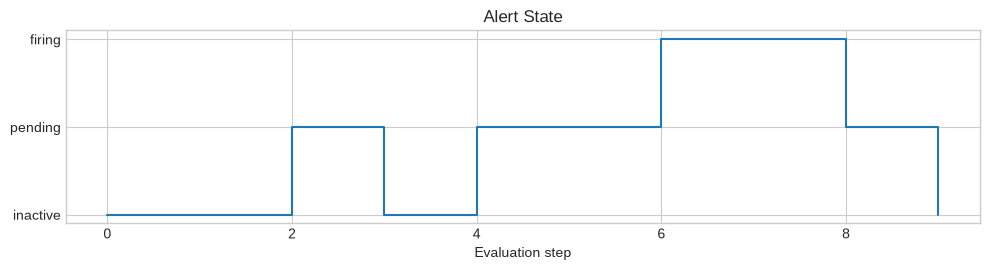

In [6]:
def simulate_alert_state(flags, for_points=1, keep_points=0):
    flags = np.asarray(flags, dtype=bool)
    states, run, remaining = [], 0, 0
    firing = False
    for flag in flags:
        run = run + 1 if flag else 0
        if run >= for_points:
            firing, remaining = True, keep_points
        elif firing and not flag and remaining > 0:
            remaining -= 1
        elif not flag or run < for_points:
            firing = False
        states.append("firing" if firing else ("pending" if flag else "inactive"))
    return np.array(states)

toy_flags = np.array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0], dtype=bool)
toy_states = simulate_alert_state(toy_flags, for_points=3, keep_points=2)
mapping = {"inactive": 0, "pending": 1, "firing": 2}
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.step(range(len(toy_states)), [mapping[s] for s in toy_states], where="post")
ax.set(yticks=[0, 1, 2], yticklabels=["inactive", "pending", "firing"],
       xlabel="Evaluation step", title="Alert State")
plt.tight_layout(); plt.show()

## 5. Detection latency 要先說是哪一段

我們保留 event source timestamp，並拆成三段：

$$
L_{detector,source}=t_{signal,source}-t_{event,source}
$$

$$
L_{policy,wall}=t_{firing,wall}-t_{signal,wall}
$$

$$
L_{notification,wall}=t_{receiver,wall}-t_{firing,wall}
$$

第一段用 source clock 才保留「延遲幾個五分鐘點」的意義；後兩段是實際系統 wall time。若要把 policy 換回 source-equivalent，可算 $S L_{policy,wall}$，但報告時一定要標明換算。`startsAt` 是 Alertmanager payload 裡的 alert onset，不等於 receiver 收到 notification 的時間。

In [7]:
LIVE_MODE = os.getenv("LAB05_LIVE_MODE", "0") == "1"
endpoints = {
    "Replayer": "http://localhost:9200/-/healthy",
    "Prometheus": "http://localhost:9090/-/healthy",
    "Alertmanager": "http://localhost:9093/-/healthy",
    "Receiver": "http://localhost:9300/-/healthy",
    "Grafana": "http://localhost:3000/api/health",
}
rows = []
for component, url in endpoints.items():
    if not LIVE_MODE:
        rows.append({"Component": component, "Status": "NOT CHECKED", "Action": "Set LAB05_LIVE_MODE=1 after Compose is healthy"})
        continue
    try:
        with urlopen(url, timeout=2) as response:
            rows.append({"Component": component, "Status": "PASS" if response.status == 200 else "FAIL", "Action": url})
    except (URLError, OSError) as error:
        rows.append({"Component": component, "Status": "FAIL", "Action": f"Check {url}: {error}"})
preflight = pd.DataFrame(rows)
display(preflight)

,Component,Status,Action
0,Replayer,NOT CHECKED,Set LAB05_LIVE_MODE=1 after Compose is healthy
1,Prometheus,NOT CHECKED,Set LAB05_LIVE_MODE=1 after Compose is healthy
2,Alertmanager,NOT CHECKED,Set LAB05_LIVE_MODE=1 after Compose is healthy
3,Receiver,NOT CHECKED,Set LAB05_LIVE_MODE=1 after Compose is healthy
4,Grafana,NOT CHECKED,Set LAB05_LIVE_MODE=1 after Compose is healthy


## 6. 實作循環：edit → check → reload → replay → observe

| 想達到的效果 | 修改位置 | 修改內容 | 觀察位置 |
| --- | --- | --- | --- |
| 過濾短 spike | Prometheus `rules.yml` | `for: 2s` | Grafana Alert State |
| 降低 flapping | Prometheus `rules.yml` | `keep_firing_for: 2s` | state transitions |
| 避免同事件重複通知 | Alertmanager YAML | `repeat_interval` | receiver deliveries |
| 合併相關 alerts | Alertmanager YAML | `group_by`, `group_wait`, `group_interval` | alerts per webhook |
| 根因抑制症狀 | Alertmanager YAML | `inhibit_rules` | Prometheus vs receiver |
| 維護期間不通知 | Grafana / Alertmanager UI | Silence | alerts visible, notification absent |
| 依嚴重度送不同對象 | Prometheus labels + Alertmanager route | warning→chat, critical→pager | receiver label |

每次修改後：

```bash
python labs/workshop/lab05_control.py check
python labs/workshop/lab05_control.py reload
python labs/workshop/lab05_control.py reset
python labs/workshop/lab05_control.py start P1 --speed 300
```

需要回到乾淨基線時只還原本 Lab 的兩份 active YAML：`python labs/workshop/lab05_control.py restore-config`。

## 7. P1 — 短 spike、persistence 與 flapping

Baseline threshold 會把一點 spike、持續異常、兩個 flapping peaks 都送進 alert state。先在 `HighAnomalyScore` 加 `for: 2s`：短 spike 無法完成 pending，但 persistent shift 仍會 firing。再加 `keep_firing_for: 2s`，比較 firing/resolved transition 是否減少。

注意：`for: 2s` 是 replay wall time；當 $S=300$，相當於 $10$ 分鐘 source time。若改 $S$，同一 YAML 的 source-time 意義也會改變。

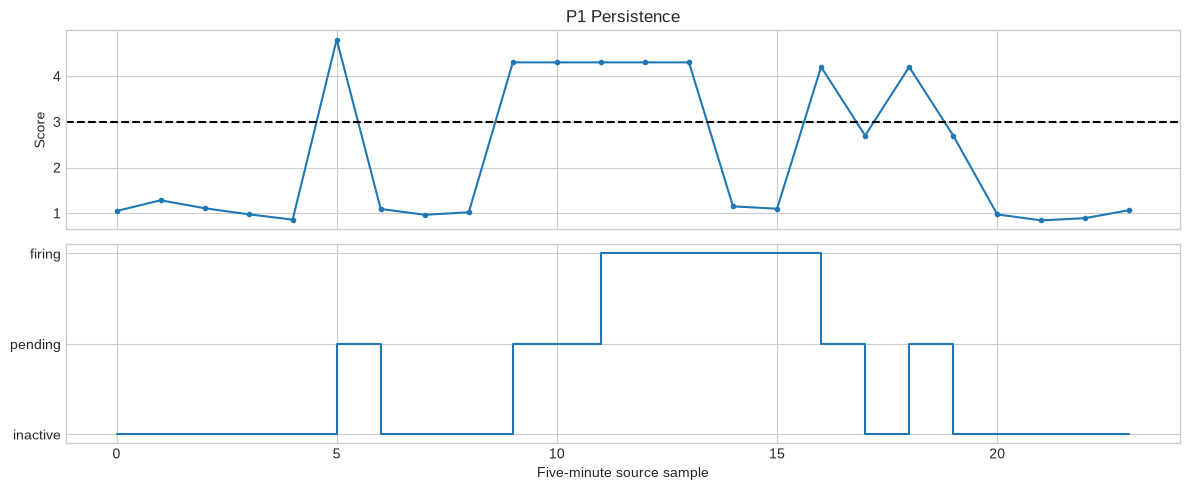

{'spike_state': np.str_('pending'), 'persistent_fires': True}


In [8]:
p1 = metrics.query("scenario_id == 'P1' and target == 'fw01'").reset_index(drop=True)
p1_flags = p1["mahalanobis_score"].gt(THRESHOLD).to_numpy()
interval = replay_interval_seconds(300, 300)
for_points = math.ceil(2 / interval) + 1
p1_states = simulate_alert_state(p1_flags, for_points=for_points, keep_points=2)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(p1["sample_index"], p1["mahalanobis_score"], marker="o", ms=3)
axes[0].axhline(THRESHOLD, color="black", ls="--")
axes[0].set(title="P1 Persistence", ylabel="Score")
axes[1].step(p1["sample_index"], [{"inactive": 0, "pending": 1, "firing": 2}[s] for s in p1_states], where="post")
axes[1].set(yticks=[0, 1, 2], yticklabels=["inactive", "pending", "firing"], xlabel="Five-minute source sample")
plt.tight_layout(); plt.show()
print({"spike_state": p1_states[5], "persistent_fires": bool((p1_states[9:14] == "firing").any())})

### Shewhart run rule 與 true hysteresis 的延伸

若 score 在 threshold 附近震盪，`keep_firing_for` 能減少通知狀態切換，但不能改變「何時進入」異常。需要幅度 hysteresis 時，另建 recording rule 或 stateful detector，使用 $h_{on}$ 與 $h_{off}$。這個延伸放在 persistence 後，是為了不把 Prometheus timer 誤講成 detector algorithm。

## 8. P2 — 三個 alerts 是否應該變三封通知？

Mahalanobis、LOF 與 packet loss 在同一 site、同一 run 先後出現。Baseline `group_by: [alertname, target, detector, run_id]` 刻意拆開；改成 `group_by: [site, run_id]` 後，`group_wait: 2s` 先等相關 alerts 到齊，`group_interval: 3s` 控制 group 更新，`repeat_interval: 6s` 控制同一 group 的重送。

Deduplication 依 alert labels 辨識同一 alert；grouping 則把多個 alert instances 放進同一 webhook。不要用 notification count 直接代替事件數。

,Policy,First-dispatch groups,Alerts represented
0,Separate by alertname/target/detector,3,3
1,Group by site/run_id,1,3


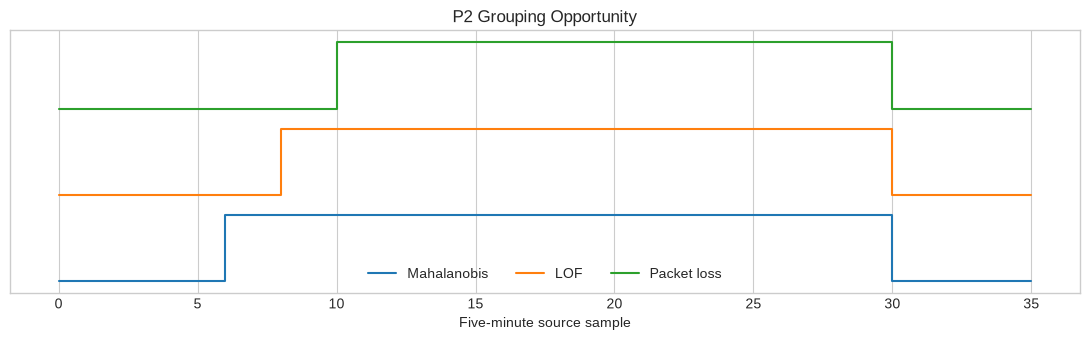

In [9]:
p2 = metrics.query("scenario_id == 'P2' and target == 'fw01'").reset_index(drop=True)
signals = pd.DataFrame({
    "Mahalanobis": p2["mahalanobis_score"].gt(THRESHOLD),
    "LOF": p2["lof_score"].gt(THRESHOLD),
    "Packet loss": p2["packet_loss_ratio"].gt(.02),
})
onsets = signals & ~signals.shift(fill_value=False)
p2_table = pd.DataFrame({
    "Policy": ["Separate by alertname/target/detector", "Group by site/run_id"],
    "First-dispatch groups": [int(onsets.sum().sum()), 1],
    "Alerts represented": [int(signals.any().sum()), int(signals.any().sum())],
})
display(p2_table)

fig, ax = plt.subplots(figsize=(11, 3.5))
for offset, column in enumerate(signals):
    ax.step(p2["sample_index"], signals[column].astype(int) + offset * 1.3, where="post", label=column)
ax.set(title="P2 Grouping Opportunity", xlabel="Five-minute source sample", yticks=[])
ax.legend(ncol=3); plt.tight_layout(); plt.show()

## 9. P3 — 根因出現後，症狀 alert 仍存在但不通知

FirewallDown 之後 WebDown、DatabaseDown 陸續出現。`inhibit_rules` 以 FirewallDown 為 source、WebDown／DatabaseDown 為 targets，並要求 `site,run_id` 相同。

Inhibition 只阻止 Alertmanager 發送 symptom notifications；Prometheus 的三個 firing alerts 都保留，方便 diagnosis 與 audit。這跟在 PromQL 直接刪掉症狀不同。

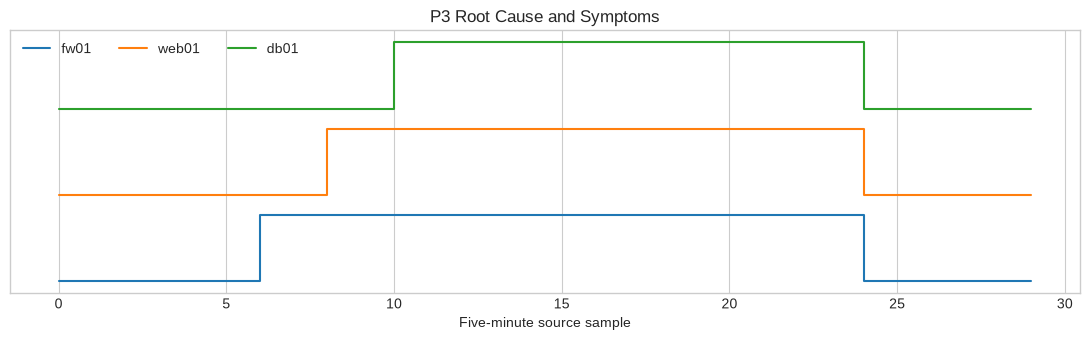

,Layer,Visible names
0,Prometheus firing alerts,"FirewallDown, WebDown, DatabaseDown"
1,Receiver after inhibition,FirewallDown


In [10]:
p3 = metrics.query("scenario_id == 'P3'")
service = p3.pivot(index="sample_index", columns="target", values="service_up")
fig, ax = plt.subplots(figsize=(11, 3.5))
for offset, target in enumerate(("fw01", "web01", "db01")):
    ax.step(service.index, (1 - service[target]) + offset * 1.3, where="post", label=target)
ax.set(title="P3 Root Cause and Symptoms", xlabel="Five-minute source sample", yticks=[])
ax.legend(ncol=3); plt.tight_layout(); plt.show()
display(pd.DataFrame({
    "Layer": ["Prometheus firing alerts", "Receiver after inhibition"],
    "Visible names": ["FirewallDown, WebDown, DatabaseDown", "FirewallDown"],
}))

## 10. P4 — Context、Silence 與 routing

一般 warning 送 `chat`，一般 critical packet loss 送 `pager`。維護區段仍讓 detector 與 Prometheus 正常顯示 alerts，但在 Grafana／Alertmanager 建立 matcher `maintenance="true"` 的 Silence，使 notification 不送出。

Silence 是有期限、可稽核的 runtime object，不應為了維護一直改 rule。Routing 使用 labels 決定 receiver；receiver 就是「Alertmanager 把 notification 送到哪個目的地」的設定名稱與 integration 集合。

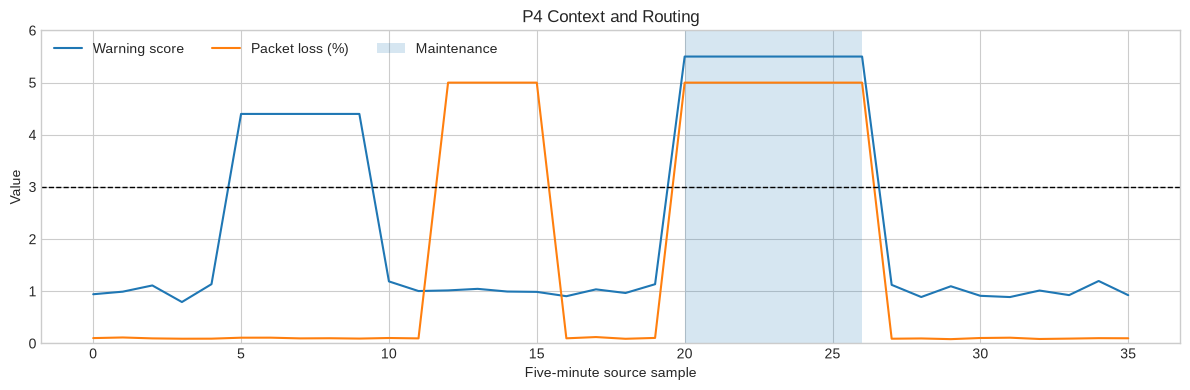

,Context,Alert visible,Receiver
0,Normal warning,True,chat
1,Normal critical,True,pager
2,Maintenance,True,silenced


In [11]:
p4 = metrics.query("scenario_id == 'P4' and target == 'fw01'").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(p4["sample_index"], p4["mahalanobis_score"], label="Warning score")
ax.plot(p4["sample_index"], p4["packet_loss_ratio"] * 100, label="Packet loss (%)")
ax.fill_between(p4["sample_index"], 0, 6, where=p4["maintenance_active"].astype(bool), alpha=.18, label="Maintenance")
ax.axhline(THRESHOLD, color="black", ls="--", lw=1)
ax.set(title="P4 Context and Routing", xlabel="Five-minute source sample", ylabel="Value", ylim=(0, 6))
ax.legend(ncol=3); plt.tight_layout(); plt.show()
display(pd.DataFrame([
    {"Context": "Normal warning", "Alert visible": True, "Receiver": "chat"},
    {"Context": "Normal critical", "Alert visible": True, "Receiver": "pager"},
    {"Context": "Maintenance", "Alert visible": True, "Receiver": "silenced"},
]))

## 11. Full incident — 把 policy 串回同一條 timeline

完整情境依序包含 nuisance spike、persistent score、flapping、multi-signal、firewall root cause 與 maintenance。請在 Grafana 拉動最近五分鐘 wall timeline，比對：score → pending/firing → grouped notification → inhibition/Silence 後的 receiver history。

```bash
python labs/workshop/lab05_control.py reset
python labs/workshop/lab05_control.py start full_incident --speed 300
```

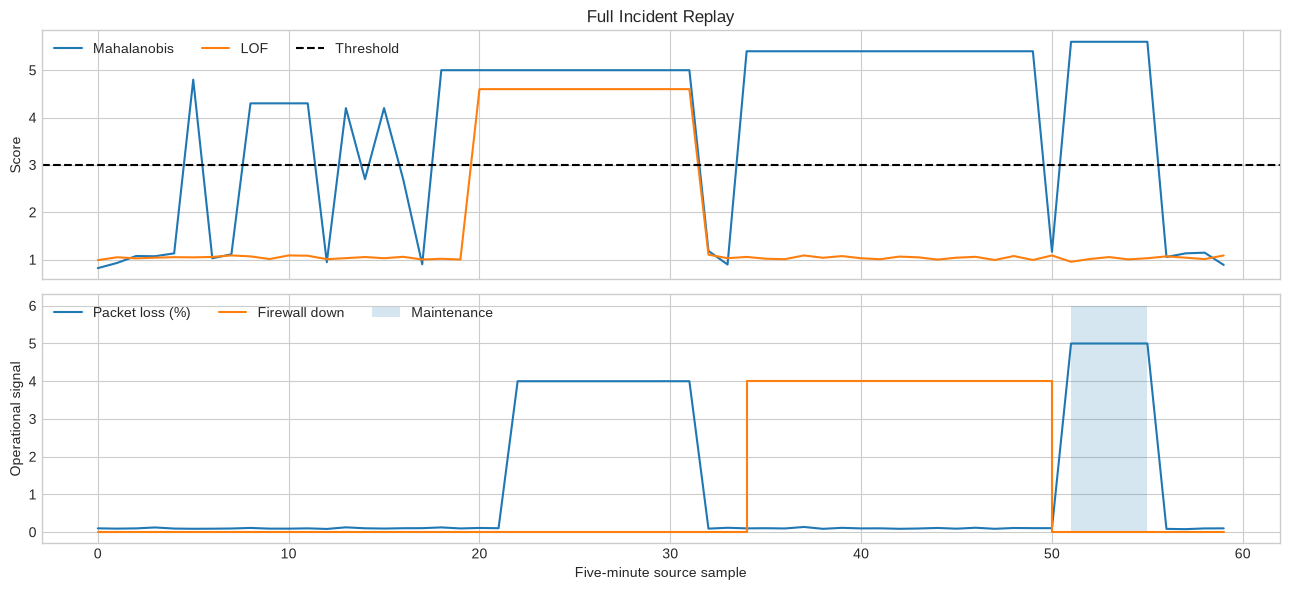

In [12]:
full = metrics.query("scenario_id == 'full_incident' and target == 'fw01'").reset_index(drop=True)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(full["sample_index"], full["mahalanobis_score"], label="Mahalanobis")
axes[0].plot(full["sample_index"], full["lof_score"], label="LOF")
axes[0].axhline(THRESHOLD, color="black", ls="--", label="Threshold")
axes[0].set(title="Full Incident Replay", ylabel="Score"); axes[0].legend(ncol=3)
axes[1].plot(full["sample_index"], full["packet_loss_ratio"] * 100, label="Packet loss (%)")
axes[1].step(full["sample_index"], (1 - full["service_up"]) * 4, where="post", label="Firewall down")
axes[1].fill_between(full["sample_index"], 0, 6, where=full["maintenance_active"].astype(bool), alpha=.18, label="Maintenance")
axes[1].set(xlabel="Five-minute source sample", ylabel="Operational signal"); axes[1].legend(ncol=3)
plt.tight_layout(); plt.show()

In [13]:
scorecard = pd.DataFrame([
    {"Scenario": "P1", "Decision": "for + keep_firing_for", "Observe": "alert episodes and transitions"},
    {"Scenario": "P2", "Decision": "grouping + notification timers", "Observe": "notifications vs contained alerts"},
    {"Scenario": "P3", "Decision": "inhibition", "Observe": "alerts remain; symptoms not notified"},
    {"Scenario": "P4", "Decision": "routing + Silence", "Observe": "receiver and maintenance context"},
    {"Scenario": "Full", "Decision": "combine policies", "Observe": "incident timeline and three latencies"},
])
display(scorecard)

,Scenario,Decision,Observe
0,P1,for + keep_firing_for,alert episodes and transitions
1,P2,grouping + notification timers,notifications vs contained alerts
2,P3,inhibition,alerts remain; symptoms not notified
3,P4,routing + Silence,receiver and maintenance context
4,Full,combine policies,incident timeline and three latencies


In [14]:
p1_episode_starts = np.flatnonzero(p1_flags & ~np.r_[False, p1_flags[:-1]])
p3_events = events.query("scenario_id == 'P3'")
checks = pd.Series({
    "five_minute_source_cadence": metrics.sort_values(["scenario_id", "target", "sample_index"]).groupby(["scenario_id", "target"])["source_timestamp"].diff().dropna().eq(pd.Timedelta(minutes=5)).all(),
    "five_scenarios_present": set(metrics["scenario_id"]) == set(SCENARIOS),
    "truth_catalog_is_separate": "event_id" not in metrics.columns and "actionable" not in metrics.columns,
    "speed_300_means_one_second": replay_interval_seconds(300, 300) == 1,
    "p1_has_four_raw_episodes": len(p1_episode_starts) == 4,
    "p1_duration_keeps_persistent": bool((p1_states[9:14] == "firing").any()) and p1_states[5] != "firing",
    "p2_has_three_related_signals": int(signals.any().sum()) == 3,
    "p3_root_cause_is_encoded": p3_events.query("event_type in ['web_down', 'db_down']")["root_cause_event_id"].notna().all(),
    "p4_has_maintenance_context": p4["maintenance_active"].sum() == 7,
    "latency_terms_are_nonnegative": all(value >= 0 for value in (0, 2, .25)),
}, name="passed")
assert checks.all(), checks[~checks]
display(checks.to_frame())

,passed
five_minute_source_cadence,True
five_scenarios_present,True
truth_catalog_is_separate,True
speed_300_means_one_second,True
p1_has_four_raw_episodes,True
p1_duration_keeps_persistent,True
p2_has_three_related_signals,True
p3_root_cause_is_encoded,True
p4_has_maintenance_context,True
latency_terms_are_nonnegative,True


## 12. 結論：值得叫醒人的不是每一次 threshold crossing

1. Detector score 先由 Prometheus 轉成有持續時間的 alert state。
2. `for:` 過濾短暫 condition；`keep_firing_for:` 降低 state flapping，但不是 two-threshold hysteresis。
3. Alertmanager 將相同 alert 去重、把相關 alerts grouping、以 inhibition／Silence 抑制不該通知的內容，再依 severity routing 到 receiver。
4. 評估時同時看 event、alert episode、notification delivery 與 incident，不能混成同一個 count。
5. Source clock 保存事件與 detector latency 的五分鐘語意；wall clock 衡量 policy 與 notification 系統本身。

最後的問題不是「detector 有沒有抓到」，而是：**這個 signal 是否需要一個人現在採取行動？**